# Perceptrons: The First Artificial Neuron

*From a nerve cell to a machine that can learn a yes/no decision.*

In [Lesson 0](00_Introduction.ipynb) we fit a straight line to data, and in
[Lesson 1](01_GradientDescent.ipynb) we learned *how* a machine finds that
line by walking downhill on a loss landscape. Both lessons predicted a
**number** (how much a seedling grows).

This lesson introduces the **perceptron** — the original artificial neuron,
invented in 1958 — and a new kind of task: predicting a **yes/no answer**
instead of a number. By the end you will be able to:

1. Describe the biological inspiration behind the perceptron, and its place
   in the history of AI.
2. Build a perceptron in code: a weighted sum plus bias, passed through a
   **step activation function**.
3. Hand-build (and then *train*) perceptrons that compute the logical **AND**
   and **OR** gates.
4. Show that a single perceptron **cannot** learn **XOR** — and explain why,
   using the idea of **linear separability**.


## 1. A spark of biology

Every neuron in your brain is a tiny decision-maker. Branch-like **dendrites**
collect electrical signals from thousands of other neurons; the **cell body**
adds them up; and if the total signal is strong enough, the neuron "fires" —
sending a pulse down its **axon** to the neurons it connects to. If the signal
is too weak, nothing happens. It is an all-or-nothing decision, made over and
over, by roughly 86 billion neurons at once.

![Biological neuron](https://raw.githubusercontent.com/cs231n/cs231n.github.io/master/assets/nn1/neuron.png)

*Image source: CS231n, Stanford University.*

That "add up the inputs, then decide" idea — stripped of all biological
detail — is exactly what an artificial neuron does.


## 2. A short history

| Year | Who | What happened |
|---|---|---|
| 1943 | Warren **McCulloch** & Walter **Pitts** | Published the first mathematical model of a neuron: a simple unit that adds up binary inputs and fires if the sum passes a threshold. They proved networks of these units could, in principle, compute any logical function. |
| 1949 | Donald **Hebb** | Proposed that learning happens by strengthening the connection between neurons that fire together — "cells that fire together, wire together." An early idea about *how* weights might be learned. |
| 1958 | Frank **Rosenblatt** (Cornell Aeronautical Laboratory) | Built the **Perceptron** — the McCulloch–Pitts neuron plus a rule for *learning its own weights from examples*, instead of a human hand-setting them. He implemented it as an actual machine, the "Mark I Perceptron," with a 20×20 grid of photocells as a retina and motorized potentiometers as adjustable weights. |
| 1958 | The New York Times | Reported (with some enthusiasm) that the Perceptron was an "embryo of an electronic computer" the Navy expected to "walk, talk, see, write, reproduce itself and be conscious of its existence." |
| 1969 | Marvin **Minsky** & Seymour **Papert** | Published the book *Perceptrons*, proving mathematically that a single perceptron can only learn problems that are **linearly separable** — and that some very simple problems (like XOR, which we'll meet below) are not. Research funding for neural networks dried up for over a decade — a period often called the first **AI winter**. |
| 1986 | Rumelhart, Hinton & Williams (and others) | Popularized **backpropagation** for training networks with *multiple layers* of neurons using smooth activation functions. Stacking perceptron-like units solves exactly the problem Minsky and Papert identified. This is where the next few lessons are headed. |

Keep that last row in the back of your mind — the "problem" we are about to
run into with a single perceptron is the entire reason multi-layer neural
networks exist.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 3. Anatomy of a perceptron

![Perceptron model](https://raw.githubusercontent.com/cs231n/cs231n.github.io/master/assets/nn1/neuron_model.jpeg)

*Image source: CS231n, Stanford University.*

A perceptron takes several inputs $x_1, x_2, \dots, x_n$, each with its own
**weight** $w_1, w_2, \dots, w_n$ saying how important that input is, plus one
extra number called the **bias** $b$. It combines them into a single weighted
sum:

$$ z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b $$

**You have already seen this equation.** In Lesson 0 we wrote a line as
$y = mx + c$: one input $x$, one weight $m$, one bias $c$. A perceptron is the
exact same weighted-sum-plus-bias idea, just generalized to handle *several*
inputs at once. (It's also exactly the model behind the "Fit a line to data"
demo in `demos/01_GradientDescent.py` — there $z$ *was* the prediction. Here
we add one more step.)

That "one more step" is what makes a perceptron a *decision-maker* instead of
a number-predictor: $z$ is passed through an **activation function** that
squashes it into a final output. The perceptron's original activation
function was the **step function**, which is what we use for the rest of this
lesson. (Other, smoother activation functions are the subject of the next
lesson.)


## 4. The step activation function

The step function is the simplest possible "decide yes or no" rule:

$$ \text{step}(z) = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases} $$

It mimics the all-or-nothing firing of a real neuron: either the evidence
($z$) crosses the threshold (zero) and the neuron "fires" (outputs 1), or it
doesn't (outputs 0). There is no in-between.


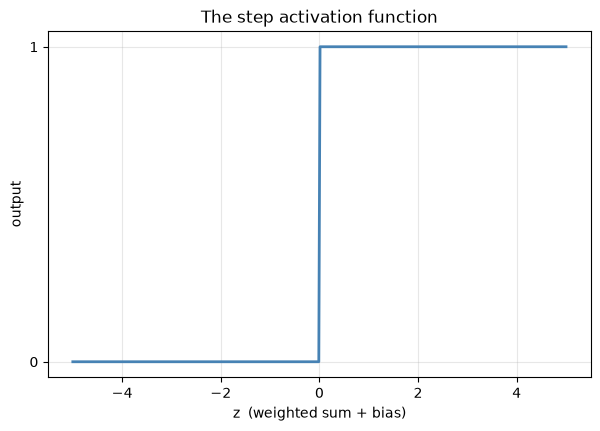

In [2]:
def step(z):
    "Step activation: outputs 1 if the weighted sum is >= 0, otherwise 0."
    return np.where(z >= 0, 1, 0)


z = np.linspace(-5, 5, 400)

plt.plot(z, step(z), color="steelblue", linewidth=2)
plt.xlabel("z  (weighted sum + bias)")
plt.ylabel("output")
plt.yticks([0, 1])
plt.title("The step activation function")
plt.show()

In [3]:
def perceptron(x, w, b):
    "A single perceptron: weighted sum of inputs + bias, through the step function."
    z = np.dot(x, w) + b
    return step(z)


# A quick sanity check with made-up numbers
print(perceptron(np.array([1.0, 0.5]), w=np.array([2.0, -1.0]), b=0.0))

1


## 5. Teaching a perceptron logic: AND and OR

Logic gates are a perfect first task for a perceptron: the inputs and the
correct answer are both just 0s and 1s. Here are all four possible pairs of
binary inputs, with the correct answers for the **AND** and **OR** gates:

| $x_1$ | $x_2$ | AND | OR |
|---|---|---|---|
| 0 | 0 | 0 | 0 |
| 0 | 1 | 0 | 1 |
| 1 | 0 | 0 | 1 |
| 1 | 1 | 1 | 1 |


In [4]:
# All four possible combinations of two binary inputs
inputs = np.array(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ]
)

and_labels = np.array([0, 0, 0, 1])
or_labels = np.array([0, 1, 1, 1])

### Hand-picking weights

Before we let the machine learn anything, let's *design* a perceptron for AND
by hand — the same way we hand-picked $(m, c)$ guesses for a line in Lesson 0.

For AND, both inputs need to be 1 before we want to fire. Weighting each input
by 1 and setting the bias to $-1.5$ does the job: the sum only reaches (or
exceeds) zero once *both* inputs are 1.


In [5]:
w_and, b_and = np.array([1.0, 1.0]), -1.5
w_or, b_or = np.array([1.0, 1.0]), -0.5

print("AND gate")
for x, target in zip(inputs, and_labels):
    pred = perceptron(x, w_and, b_and)
    print(f"  x = {x}, target = {target}, perceptron output = {pred}")

print("\nOR gate")
for x, target in zip(inputs, or_labels):
    pred = perceptron(x, w_or, b_or)
    print(f"  x = {x}, target = {target}, perceptron output = {pred}")

AND gate
  x = [0 0], target = 0, perceptron output = 0
  x = [0 1], target = 0, perceptron output = 0
  x = [1 0], target = 0, perceptron output = 0
  x = [1 1], target = 1, perceptron output = 1

OR gate
  x = [0 0], target = 0, perceptron output = 0
  x = [0 1], target = 1, perceptron output = 1
  x = [1 0], target = 1, perceptron output = 1
  x = [1 1], target = 1, perceptron output = 1


### Seeing the decision as a line

A 2-input perceptron fires wherever $w_1 x_1 + w_2 x_2 + b \ge 0$. The
boundary between "fires" and "doesn't fire" is where that sum is exactly
zero — which, rearranged, is just $x_2 = -\dfrac{w_1}{w_2} x_1 - \dfrac{b}{w_2}$:
a **straight line** in the input space, same as $y = mx + c$ from Lesson 0.
Everything on one side fires (output 1); everything on the other side doesn't
(output 0).


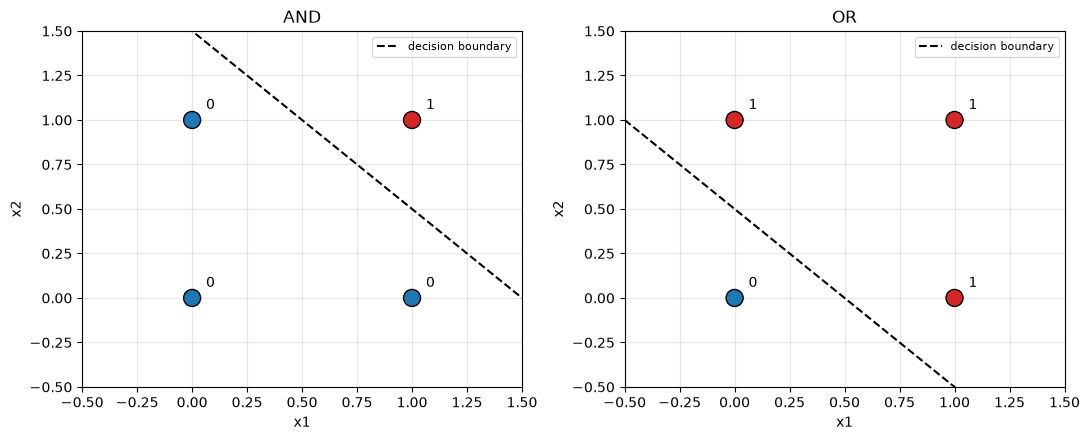

In [6]:
def plot_decision_boundary(inputs, labels, w, b, title, ax=None):
    "Scatter the 4 points (colored by label) plus the perceptron's boundary line."
    if ax is None:
        _, ax = plt.subplots()

    colors = np.where(labels == 1, "tab:red", "tab:blue")
    ax.scatter(inputs[:, 0], inputs[:, 1], c=colors, s=150, zorder=3, edgecolor="black")
    for (x1, x2), label in zip(inputs, labels):
        ax.annotate(str(label), (x1, x2), textcoords="offset points", xytext=(10, 8))

    if w is not None and abs(w[1]) > 1e-9:
        x1_line = np.linspace(-0.5, 1.5, 100)
        x2_line = -(w[0] * x1_line + b) / w[1]
        ax.plot(x1_line, x2_line, "k--", label="decision boundary")
        ax.legend(loc="upper right", fontsize=8)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_decision_boundary(inputs, and_labels, w_and, b_and, "AND", ax=axes[0])
plot_decision_boundary(inputs, or_labels, w_or, b_or, "OR", ax=axes[1])
plt.tight_layout()
plt.show()

## 6. Learning the weights: the perceptron rule

Hand-picking weights is fine for two inputs, but the whole point of Lesson 1
was to let the *machine* find the numbers. Can we use gradient descent here?

Not quite — not yet. Gradient descent needs a **slope** to follow downhill,
but the step function is flat everywhere except at $z = 0$, where it jumps
straight up with no slope at all. There is nothing for gradient descent to
grab onto. (This is exactly the limitation the *next* lesson's smoother
activation functions fix.)

Instead, Rosenblatt came up with a rule that needs no calculus at all — just
compare the prediction to the target and nudge the weights toward it:

$$ w_i \leftarrow w_i + (\text{learning rate}) \times (\text{target} - \text{prediction}) \times x_i $$
$$ b \leftarrow b + (\text{learning rate}) \times (\text{target} - \text{prediction}) $$

If the perceptron is correct, `target - prediction` is 0 and nothing changes.
If it fires when it shouldn't, the error is negative and the weights shrink;
if it stays silent when it should fire, the error is positive and the weights
grow. It's the same "search by making small adjustments" spirit as gradient
descent — just guided by a mistake count instead of a slope.


In [7]:
def train_perceptron(inputs, labels, learning_rate=0.1, n_epochs=10):
    "Learn weights and bias with Rosenblatt's perceptron rule."
    n_features = inputs.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    history = {"w": [w.copy()], "b": [b], "errors": []}

    for _ in range(n_epochs):
        n_errors = 0
        for x, target in zip(inputs, labels):
            prediction = perceptron(x, w, b)
            error = target - prediction
            w = w + learning_rate * error * x
            b = b + learning_rate * error
            n_errors += int(error != 0)
        history["w"].append(w.copy())
        history["b"].append(b)
        history["errors"].append(n_errors)

    return w, b, history

In [8]:
w_learned, b_learned, history_and = train_perceptron(inputs, and_labels, learning_rate=0.1, n_epochs=10)

print(f"Learned weights: w = {w_learned}, b = {b_learned:.2f}")
print(f"Mistakes per epoch: {history_and['errors']}")

Learned weights: w = [0.2 0.1], b = -0.20
Mistakes per epoch: [2, 3, 3, 0, 0, 0, 0, 0, 0, 0]


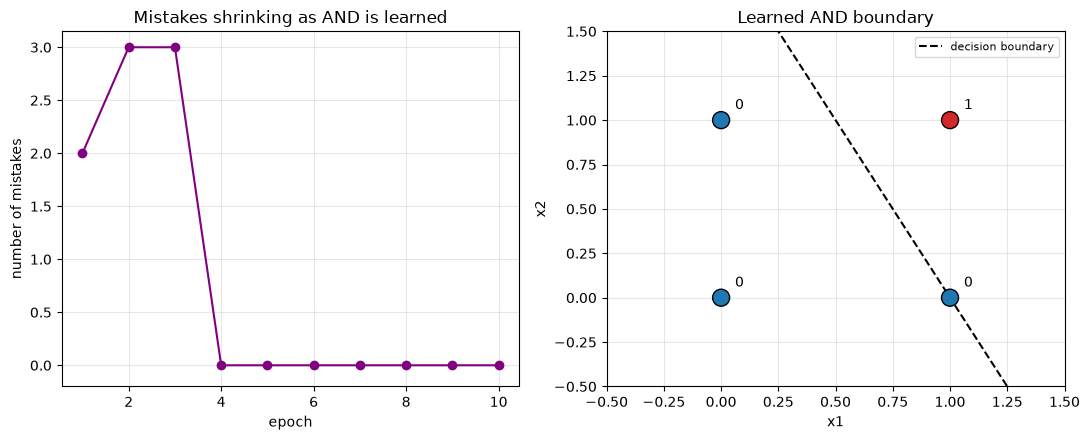

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

epochs = range(1, len(history_and["errors"]) + 1)
ax1.plot(epochs, history_and["errors"], "o-", color="purple")
ax1.set_xlabel("epoch")
ax1.set_ylabel("number of mistakes")
ax1.set_title("Mistakes shrinking as AND is learned")
ax1.set_ylim(bottom=-0.2)

plot_decision_boundary(inputs, and_labels, w_learned, b_learned, "Learned AND boundary", ax=ax2)
plt.tight_layout()
plt.show()

Just like the loss curve in Lesson 1, the mistake count drops as training
proceeds — and once it hits zero, the perceptron has found a line that
perfectly separates the two classes. Let's confirm the same recipe learns OR.


Learned weights: w = [0.1 0.1], b = -0.10
Mistakes per epoch: [2, 2, 1, 0, 0, 0, 0, 0, 0, 0]


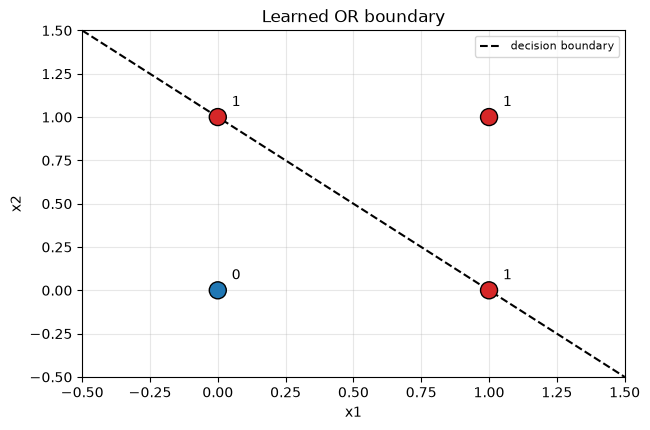

In [10]:
w_or_learned, b_or_learned, history_or = train_perceptron(inputs, or_labels, learning_rate=0.1, n_epochs=10)

print(f"Learned weights: w = {w_or_learned}, b = {b_or_learned:.2f}")
print(f"Mistakes per epoch: {history_or['errors']}")

plot_decision_boundary(inputs, or_labels, w_or_learned, b_or_learned, "Learned OR boundary")
plt.show()

## 7. The problem: XOR

**XOR** ("exclusive or") fires when *exactly one* input is 1 — not neither,
and not both:

| $x_1$ | $x_2$ | XOR |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Let's throw the exact same learning rule at it.


In [11]:
xor_labels = np.array([0, 1, 1, 0])

w_xor, b_xor, history_xor = train_perceptron(inputs, xor_labels, learning_rate=0.1, n_epochs=20)

print(f"Learned weights: w = {w_xor}, b = {b_xor:.2f}")
print(f"Mistakes per epoch: {history_xor['errors']}")

Learned weights: w = [-0.1  0. ], b = 0.00
Mistakes per epoch: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


Unlike AND and OR, the mistake count for XOR never reaches zero — it just
bounces around forever, no matter how long we train or which weights we try.
Something is fundamentally different about this problem.


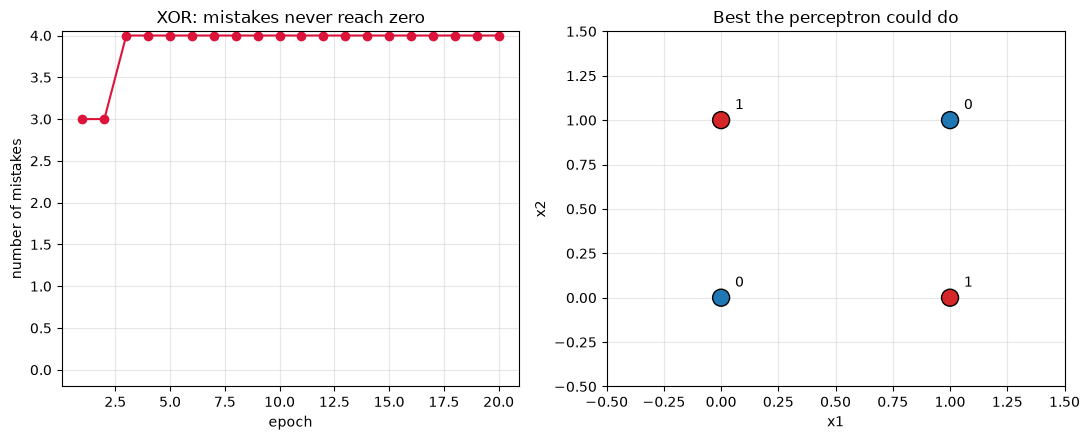

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

epochs = range(1, len(history_xor["errors"]) + 1)
ax1.plot(epochs, history_xor["errors"], "o-", color="crimson")
ax1.set_xlabel("epoch")
ax1.set_ylabel("number of mistakes")
ax1.set_title("XOR: mistakes never reach zero")
ax1.set_ylim(bottom=-0.2)

plot_decision_boundary(inputs, xor_labels, w_xor, b_xor, "Best the perceptron could do", ax=ax2)
plt.tight_layout()
plt.show()

## 8. Linear separability

Here's why: look at where the red (1) and blue (0) dots sit for XOR. They
alternate corner to corner. **No single straight line** can put both red dots
on one side and both blue dots on the other — try drawing one on paper. A few
candidate lines make the point:


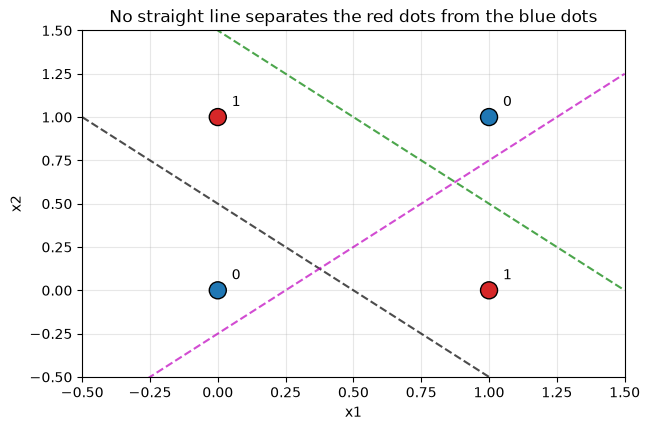

In [13]:
fig, ax = plt.subplots()

colors = np.where(xor_labels == 1, "tab:red", "tab:blue")
ax.scatter(inputs[:, 0], inputs[:, 1], c=colors, s=150, zorder=3, edgecolor="black")
for (x1, x2), label in zip(inputs, xor_labels):
    ax.annotate(str(label), (x1, x2), textcoords="offset points", xytext=(10, 8))

x1_line = np.linspace(-0.5, 1.5, 100)
candidate_lines = [
    (1, 1, -0.5, "k--"),
    (1, 1, -1.5, "g--"),
    (1, -1, -0.25, "m--"),
]
for w1, w2, b, style in candidate_lines:
    x2_line = -(w1 * x1_line + b) / w2
    ax.plot(x1_line, x2_line, style, alpha=0.7)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("No straight line separates the red dots from the blue dots")
plt.show()

A dataset is **linearly separable** if a single straight line (or, with more
inputs, a flat plane / hyperplane) can perfectly separate its classes. AND and
OR are linearly separable — we drew the separating lines above. **XOR is
not** — and since a perceptron's decision boundary is *always* a straight
line, no choice of weights and bias, learned or hand-picked, will ever solve
it.

This is precisely the limitation Minsky and Papert proved in 1969. It isn't a
bug in our training code — it's a mathematical ceiling on what *one*
perceptron can represent. The fix, which the rest of this course builds
toward, is to **stack** perceptron-like units into layers and give them
smoother activation functions — a multi-layer network can bend its decision
boundary into a curve, and curves can separate XOR just fine.


## 9. Recap

- A perceptron mimics a biological neuron: sum up weighted inputs plus a
  bias, $z = \mathbf{w} \cdot \mathbf{x} + b$ — the same weighted-sum idea
  as the line $y = mx + c$ from Lesson 0, generalized to many inputs.
- The **step activation function** turns that sum into an all-or-nothing
  decision: fire (1) if $z \ge 0$, otherwise stay silent (0).
- Rosenblatt's **perceptron learning rule** adjusts weights toward the
  correct answer using only the size of the mistake — no slope required,
  because the step function has none to give.
- A single perceptron can learn **AND** and **OR** (both linearly separable)
  but **cannot** learn **XOR** (not linearly separable) — a hard limit on
  what one straight-line decision boundary can represent.
- This limitation, proven by Minsky and Papert in 1969, stalled neural
  network research for years — until multi-layer networks with smoother
  activation functions (next lesson) solved it.


## 10. Your turn — exercises

1. **NAND and NOR.** These gates are just AND and OR with the answer flipped.
   Find weights (by hand, or by training) that solve NAND and NOR. *Hint:
   what happens if you negate the weights and bias of a working AND/OR
   perceptron?*
2. **Learning rate.** Retrain the AND perceptron with `learning_rate = 0.01`
   and again with `learning_rate = 1.0`. Does it still converge? How many
   epochs does each take?
3. **Different starting weights.** In `train_perceptron`, the weights start at
   zero. Change the starting point to random small numbers (e.g.
   `np.random.uniform(-1, 1, size=n_features)`) and retrain AND a few times.
   Does it still always converge, and to the *same* line each time?
4. **Try to cheat XOR.** Hand-pick weights `w` and `b` and see how many of the
   4 XOR cases you can get right with a single perceptron. Can you ever beat
   3 out of 4?
5. **Three inputs.** Build a perceptron for the 3-input function "fire if at
   least two of the three inputs are 1" (majority vote). Is it linearly
   separable? Try hand-picking weights, then confirm with
   `train_perceptron`.


In [14]:
# Space for your experiments